## Settings & imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

DATASET = "Merkuriusz_indicators"

PREPROCESSING_METHOD = config["preprocessing_method"]
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]

MULTIPLICATION_WEIGHTS = config["multiplication_weights"]

FIGURES_PATH = config["figures_path"][DATASET.split('_')[0]]

MERKURIUSZ_RESULTS_PATH = config["ready_results_path"][DATASET.split('_')[0]]

PREPROCESSED_DATA_PATH = config["preprocessed_data_path"][DATASET.split('_')[0]]

## Loading the data

In [3]:
def load_prediction(results_path, elements_to_keep):
        
    input_data = np.loadtxt(results_path, delimiter=',')
    df = pd.DataFrame(data=input_data, columns=elements_to_keep)
    
    return df

In [4]:
if DATASET.endswith('_indicators'):
    df = load_target_data(PREPROCESSED_DATA_PATH, ELEMENTS_TO_KEEP, header=0)
else:
    df = load_prediction(MERKURIUSZ_RESULTS_PATH, ELEMENTS_TO_KEEP_NO_FE)

y_true = load_target_data(PREPROCESSED_DATA_PATH, ['name'], header=0)['Sample_id']

## Preprocessing

1. In this case, we skip removal of outer samples - it was only done for training examples to ensure the quality of training dataset. No need to do it on target dataset.

2. We skip removing columns from outside ELEMENTS_TO_KEEP list, as we have already done it during dataset loading.

3. There is no missing data in target dataset, so there is no need to remove anything.

In [5]:
df.dropna().shape == df.shape

True

4. For indicators, we do the same preprocessing as for the training dataset (-> notebooks/inks_nn_regression.ipynb). First, we set negative numbers to zero.

In [6]:
if DATASET.endswith('_indicators'):
    df = set_negative_to_zero_v2(df, ELEMENTS_TO_KEEP)

5. Let's divide the indicators by weights.

In [7]:
if DATASET.endswith('_indicators'):
    df = divide_by_weights(df, ELEMENTS_TO_KEEP, suffix='', weights=MULTIPLICATION_WEIGHTS)

6. We normalize to Fe (only indicators).

In [8]:
if DATASET.endswith('_indicators'):
    df = normalize_to_Fe_v2(df, ELEMENTS_TO_KEEP)

7. Finally, let's reset the index.

In [9]:
if DATASET.endswith('_indicators'):
    df = delete_elements_v3(df, ELEMENTS_TO_KEEP_NO_FE)

### Converting to np.array

In [10]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [11]:
if DATASET == 'Merkuriusz_indicators':

    X = transform_data(X, PREPROCESSING_METHOD)

### PCA - all points

In [12]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

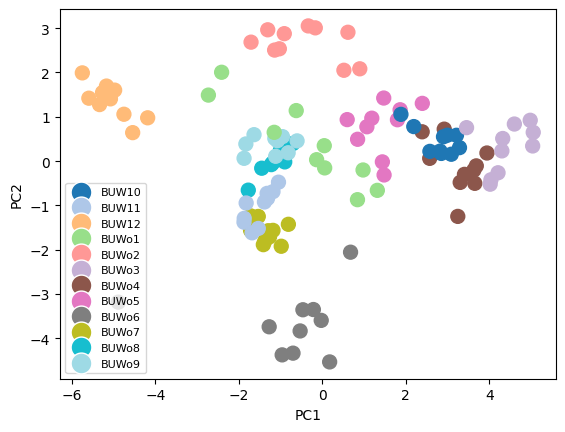

In [13]:
visualise_pca(X_pca, y_true, figures_path=FIGURES_PATH + DATASET)

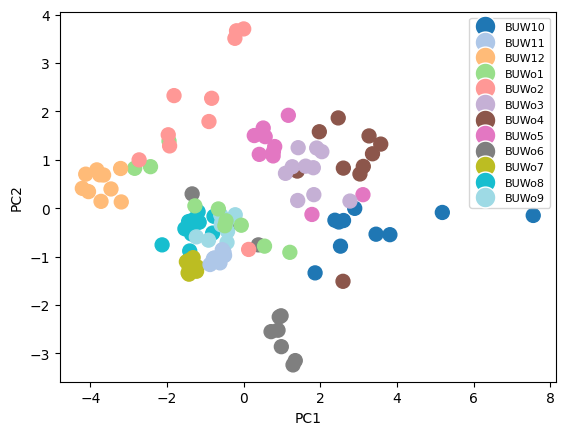

In [16]:
visualise_pca(X_pca, y_true, figures_path=FIGURES_PATH + DATASET)

### tSNE - all points

In [14]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

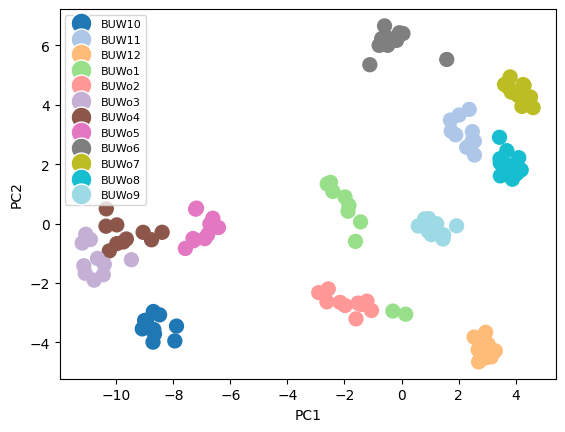

In [15]:
visualise_pca(X_tsne, y_true, figures_path=FIGURES_PATH + DATASET, method_name='tsne')

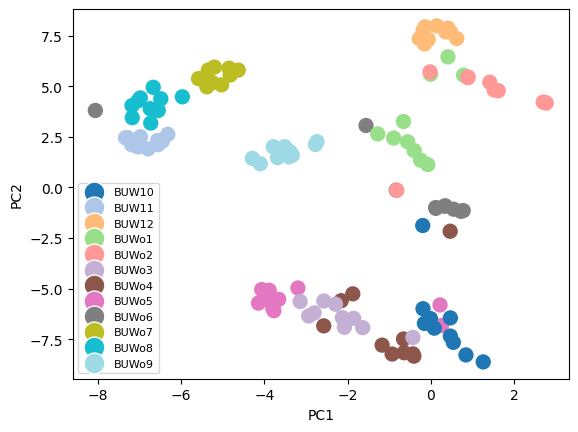

In [15]:
visualise_pca(X_tsne, y_true, figures_path=FIGURES_PATH + DATASET, method_name='tsne')